# VISTA Demo: POPE Evaluation with LLaVA 1.5 7B

This notebook runs the **VISTA** pipeline on the **POPE** dataset using **LLaVA 1.5 7B** for a **few examples** (quick demo).

**Prerequisites:**
- **LLaVA 1.5 7B**: Set `LLAVA_MODEL_PATH` in the config cell to your checkpoint (e.g. `../download_models/llava-v1.5-7b` or absolute path). The repo default is `../download_models/llava-v1.5-7b` relative to the VISTA folder.
- **COCO**: Set `COCO_DATA_PATH` to your MSCOCO 2014 val images folder (containing `COCO_val2014_*.jpg`).

**Options:**
- `NUM_EXAMPLES`: number of POPE samples (e.g. 5–10 for a quick run).
- `USE_VSV`: Visual Steering Vectors (2 extra forwards per example).
- `USE_LOGITS_AUG`: Self-Logits Augmentation (SLA).
- `POPE_TYPE`: `"random"`, `"popular"`, or `"adversarial"`.

In [3]:
# Install correct torch/torchvision for RTX 5090 (sm_120 Blackwell) — run this FIRST
# Must run before any 'import torch' so the kernel picks up the right version.
import subprocess, sys

def _torch_ok():
    try:
        import torch
        return '2.10' in torch.__version__ and 'cu128' in torch.__version__
    except Exception:
        return False

if not _torch_ok():
    print('Installing torch 2.10.0+cu128 and torchvision 0.25.0+cu128 ...')
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '-q',
        'torch==2.10.0+cu128', 'torchvision==0.25.0+cu128',
        '--index-url', 'https://download.pytorch.org/whl/cu128',
    ], check=True)
    print('Done. Please RESTART THE KERNEL now and re-run all cells.')
    raise SystemExit('Kernel restart required after torch installation.')
else:
    import torch, torchvision
    print(f'torch {torch.__version__} / torchvision {torchvision.__version__} — OK')


torch 2.10.0+cu128 / torchvision 0.25.0+cu128 — OK


In [3]:
# Configuration: run this cell first and set paths for your environment
import os
import sys

# Ensure VISTA root is on the path. If you open the notebook from VISTA/, cwd is usually VISTA/.
VISTA_ROOT = os.getcwd()
if os.path.basename(VISTA_ROOT) != 'VISTA':
    # If cwd is project root, use VISTA subfolder
    VISTA_ROOT = os.path.join(os.getcwd(), 'VISTA')
    if not os.path.isdir(VISTA_ROOT):
        VISTA_ROOT = os.getcwd()
sys.path.insert(0, VISTA_ROOT)
os.chdir(VISTA_ROOT)

# --- LLaVA 1.5 7B: set path to your checkpoint ---
LLAVA_MODEL_PATH = os.path.expanduser("../download_models/llava-v1.5-7b")  # or absolute path, e.g. "/data/llava-v1.5-7b"
MODEL_NAME = "llava-1.5"  # LLaVA 1.5 7B (do not change for this demo)

# --- Data ---
COCO_DATA_PATH = os.path.expanduser("../download_datasets/COCO_2014/val2014")  # MSCOCO 2014 val images
POPE_TYPE = "random"     # one of: random, popular, adversarial

# --- Few examples for quick demo ---
NUM_EXAMPLES = 5
MAX_NEW_TOKENS = 32
SEED = 1994

# --- VISTA options ---
USE_VSV = True
USE_LOGITS_AUG = True
VSV_LAMBDA = 0.01
LOGITS_LAYERS = "25,30"
LOGITS_ALPHA = 0.3

print("VISTA_ROOT:", VISTA_ROOT)
print("LLaVA 7B path:", LLAVA_MODEL_PATH)
print("COCO_DATA_PATH:", COCO_DATA_PATH)
print("NUM_EXAMPLES:", NUM_EXAMPLES)

VISTA_ROOT: /workspace/VISTA
LLaVA 7B path: ../download_models/llava-v1.5-7b
COCO_DATA_PATH: ../download_datasets/COCO_2014/val2014
NUM_EXAMPLES: 5


In [13]:
pip install hf_transfer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 19.8 MB/s  0:00:00

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Download LLaVA 1.5 7B weights from HuggingFace Hub (skips if already present)
import os, subprocess, sys

HF_REPO = "liuhaotian/llava-v1.5-7b"
local_path = os.path.abspath(LLAVA_MODEL_PATH)

if os.path.isdir(local_path) and any(
    f.endswith((".bin", ".safetensors")) for f in os.listdir(local_path)
):
    print(f"Model weights already found at: {local_path}\nSkipping download.")
else:
    print(f"Downloading {HF_REPO} → {local_path}  (this may take ~15 GB and several minutes) ...")
    os.makedirs(local_path, exist_ok=True)

    # Ensure huggingface_hub is available
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "huggingface_hub[cli]"], check=True)

    from huggingface_hub import snapshot_download
    snapshot_download(
        repo_id=HF_REPO,
        local_dir=local_path,
        local_dir_use_symlinks=False,   # copy files, not symlinks
        ignore_patterns=["*.msgpack", "flax_model*", "tf_model*", "rust_model*"],
    )
    print(f"Download complete: {local_path}")

Model weights already found at: /workspace/download_models/llava-v1.5-7b
Skipping download.


In [4]:
# Download COCO 2014 val images (skips if already present)
import os, zipfile, urllib.request

COCO_VAL_URL = 'http://images.cocodataset.org/zips/val2014.zip'
coco_local   = os.path.abspath(COCO_DATA_PATH)   # e.g. ../download_datasets/COCO_2014/val2014
coco_root    = os.path.dirname(coco_local)        # e.g. ../download_datasets/COCO_2014
zip_path     = os.path.join(coco_root, 'val2014.zip')

if os.path.isdir(coco_local) and len(os.listdir(coco_local)) > 0:
    print(f'COCO val2014 already found at: {coco_local} — skipping download.')
else:
    os.makedirs(coco_root, exist_ok=True)
    if not os.path.exists(zip_path):
        print(f'Downloading COCO 2014 val images (~6.2 GB) to {zip_path} ...')
        def _progress(block_num, block_size, total_size):
            downloaded = block_num * block_size
            pct = min(downloaded / total_size * 100, 100) if total_size > 0 else 0
            print(f'\r  {pct:.1f}%  ({downloaded/1e9:.2f} / {total_size/1e9:.2f} GB)', end='', flush=True)
        urllib.request.urlretrieve(COCO_VAL_URL, zip_path, reporthook=_progress)
        print('\n  Download complete.')
    else:
        print(f'Zip already exists at {zip_path}, skipping re-download.')

    print(f'Extracting to {coco_root} ...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(coco_root)
    os.remove(zip_path)
    print(f'Done. Images at: {coco_local}')

Zip already exists at /workspace/download_datasets/COCO_2014/val2014.zip, skipping re-download.
Extracting to /workspace/download_datasets/COCO_2014 ...


BadZipFile: File is not a zip file

In [6]:
# Pin torch/torchvision to cu128 builds that support RTX 5090 (sm_120 Blackwell)
# This must run BEFORE the environment.yml install so the correct versions win.
import subprocess, sys, os

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch==2.10.0+cu128', 'torchvision==0.25.0+cu128',
    '--index-url', 'https://download.pytorch.org/whl/cu128',
], check=True)
print('torch + torchvision (cu128) pinned.')

# Install all other dependencies from environment.yml
# Packages managed separately (torch stack) are skipped to avoid overwriting.
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyyaml'], check=True)
import yaml

SKIP_PKGS = {'torch', 'torchvision', 'torchaudio', 'triton',
             'nvidia-cublas-cu12', 'nvidia-cuda-cupti-cu12', 'nvidia-cuda-nvrtc-cu12',
             'nvidia-cuda-runtime-cu12', 'nvidia-cudnn-cu12', 'nvidia-cufft-cu12',
             'nvidia-curand-cu12', 'nvidia-cusolver-cu12', 'nvidia-cusparse-cu12',
             'nvidia-nccl-cu12', 'nvidia-nvjitlink-cu12', 'nvidia-nvtx-cu12'}

env_yml_path = os.path.join(os.getcwd(), 'environment.yml')
with open(env_yml_path) as f:
    env = yaml.safe_load(f)

pip_packages = []
for dep in env.get('dependencies', []):
    if isinstance(dep, dict) and 'pip' in dep:
        pip_packages.extend(dep['pip'])

# Filter out packages we manage separately
def _pkg_name(spec):
    import re
    return re.split(r'[=><!@]', spec)[0].strip().lower().replace('-', '_').replace('.', '_')

to_install = [p for p in pip_packages if _pkg_name(p) not in
              {s.lower().replace('-','_').replace('.','_') for s in SKIP_PKGS}]
skipped_managed = len(pip_packages) - len(to_install)

print(f'Found {len(pip_packages)} pip packages; skipping {skipped_managed} managed packages.')
print('Installing the rest one by one (failures are skipped)...\n')

failed = []
for pkg in to_install:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', pkg],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        failed.append(pkg)
        print(f'  [SKIP] {pkg}')
    else:
        print(f'  [OK]   {pkg}')

print(f'\nDone. {len(to_install)-len(failed)}/{len(to_install)} packages installed.')
if failed:
    print('Could not install:', ', '.join(failed))



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


torch + torchvision (cu128) pinned.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


Found 99 pip packages; skipping 14 managed packages.
Installing the rest one by one (failures are skipped)...

  [OK]   accelerate==0.31.0
  [OK]   aiohappyeyeballs==2.4.3
  [OK]   aiohttp==3.10.9
  [OK]   aiosignal==1.3.1
  [OK]   annotated-types==0.7.0
  [OK]   antlr4-python3-runtime==4.9.3
  [OK]   anyio==4.6.0
  [OK]   async-timeout==4.0.3
  [OK]   attrs==24.2.0
  [OK]   bertviz==1.4.0
  [OK]   boto3==1.35.35
  [OK]   botocore==1.35.35
  [OK]   braceexpand==0.1.7
  [OK]   click==8.1.7
  [OK]   contourpy==1.3.0
  [OK]   cycler==0.12.1
  [OK]   datasets==3.0.1
  [OK]   decord==0.6.0
  [OK]   dill==0.3.8
  [OK]   distro==1.9.0
  [OK]   docker-pycreds==0.4.0
  [OK]   einops==0.8.0
  [OK]   fonttools==4.54.1
  [OK]   frozenlist==1.4.1
  [OK]   fsspec==2024.6.1
  [OK]   gitdb==4.0.11
  [OK]   gitpython==3.1.43
  [OK]   h11==0.14.0
  [OK]   httpcore==1.0.6
  [OK]   httpx==0.27.2
  [OK]   huggingface-hub==0.25.1
  [OK]   imageio==2.35.1
  [OK]   iopath==0.1.10
  [OK]   ipdb==0.13.13
  [OK]

In [7]:
# Imports (must run after path setup)
import sys, json

# ── Patch 1: make register_fake idempotent ──────────────────────────────────
# torch 2.10 registers _dtensor ops on startup; transformers/accelerate try to
# register them again, causing a RuntimeError. Silently skip duplicates.
import torch
_orig_register_fake = torch.library.register_fake
def _safe_register_fake(op, fn=None, **kwargs):
    try:
        return _orig_register_fake(op, fn, **kwargs) if fn is not None \
               else _orig_register_fake(op, **kwargs)
    except RuntimeError as _e:
        if 'already has an fake impl' in str(_e) or 'already has a fake impl' in str(_e):
            return (lambda f: f) if fn is None else fn   # no-op decorator
        raise
torch.library.register_fake = _safe_register_fake

# ── Patch 2: guard torchvision re-import ────────────────────────────────────
# Only purge torchvision when it is partially initialized (missing 'extension').
# Re-importing a healthy torchvision causes double-registration of roi_align etc.
_tv = sys.modules.get('torchvision')
_tv_healthy = _tv is not None and hasattr(_tv, 'extension') and hasattr(_tv, 'ops')
if not _tv_healthy:
    for _key in list(sys.modules.keys()):
        if 'torchvision' in _key:
            del sys.modules[_key]

import numpy as np
if not _tv_healthy:
    import torchvision
    import torchvision.ops
else:
    import torchvision
from torch.utils.data import DataLoader, Subset

import myutils
from anchor import POPE_PATH
from eval_data_loader import POPEDataSet
from llava.utils import disable_torch_init
from model_loader import ModelLoader
from steering_vector import obtain_vsv, add_logits_flag, remove_logits_flag
from llm_layers import add_vsv_layers, remove_vsv_layers

print('All imports OK.')


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FlashAttention is not installed.
FlashAttention is not installed.
FlashAttention is not installed.
All imports OK.


In [8]:
# Seed and disable torch init for reproducibility / faster load
myutils.seed_everything(42)
disable_torch_init()

# Use notebook's LLaVA path for LLaVA 7B (override model_loader default)
import model_loader as _ml
_orig_load_model = _ml.ModelLoader.load_model
def _patched_load_model(self):
    if self.model_name == "llava-1.5":
        path = os.path.expanduser(LLAVA_MODEL_PATH)
        if not os.path.exists(path):
            raise FileNotFoundError(f"LLaVA 7B checkpoint not found at {path}. Set LLAVA_MODEL_PATH in the config cell.")
        self.tokenizer, self.vlm_model, self.image_processor, self.llm_model = _ml.load_llava_model(path)
        return
    _orig_load_model(self)
_ml.ModelLoader.load_model = _patched_load_model

# Load LLaVA 1.5 7B (this may take a minute and requires GPU)
print(f"Loading {MODEL_NAME} (LLaVA 7B) from {LLAVA_MODEL_PATH}...")
model_loader = ModelLoader(MODEL_NAME)
print("Model loaded.")

You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.


Loading llava-1.5 (LLaVA 7B) from ../download_models/llava-v1.5-7b...


/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


use LN for projection:  False


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.80it/s]


Model loaded.


In [9]:
# Load POPE dataset and take a small subset
pope_path = POPE_PATH[POPE_TYPE]
pope_dataset = POPEDataSet(
    pope_path=pope_path,
    data_path=COCO_DATA_PATH,
    trans=model_loader.image_processor,
)
if NUM_EXAMPLES > 0 and NUM_EXAMPLES < len(pope_dataset):
    indices = np.random.choice(len(pope_dataset), NUM_EXAMPLES, replace=False)
    pope_dataset = Subset(pope_dataset, indices)

pope_loader = DataLoader(
    pope_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    drop_last=False,
)
template = myutils.prepare_template(type('Args', (), {'model': MODEL_NAME})())

print(f"POPE type: {POPE_TYPE}, number of examples: {len(pope_dataset)}")

POPE type: random, number of examples: 5


In [10]:
# Build a minimal args object for steering/logits options
class Args:
    pass
args = Args()
args.vsv = USE_VSV
args.vsv_lambda = VSV_LAMBDA
args.layers = None
args.logits_aug = USE_LOGITS_AUG
args.logits_layers = LOGITS_LAYERS
args.logits_alpha = LOGITS_ALPHA
args.model = MODEL_NAME
args.do_sample = False
args.top_p = 0.9
args.top_k = 0
args.max_new_tokens = MAX_NEW_TOKENS
args.num_beams = 1
args.no_repeat_ngram_size = None
args.temperature = 1.0
args.repetition_penalty = 1.0

In [11]:
# Run inference: baseline (no VSV/SLA) vs VISTA (VSV + SLA) for each example
from tqdm import tqdm

def run_inference(loader, use_vsv, use_sla):
    """Run model inference over loader with given VISTA flags."""
    args.vsv = use_vsv
    args.logits_aug = use_sla
    records = []
    for data in tqdm(loader, desc=f'VSV={use_vsv} SLA={use_sla}'):
        image      = data['image']
        query      = data['query']
        label      = data['label'].tolist()
        image_path = data['image_path']
        with torch.inference_mode():
            with myutils.maybe_autocast(MODEL_NAME, model_loader.vlm_model.device):
                questions, kwargs = model_loader.prepare_inputs_for_model(template, query, image)
                if use_vsv:
                    neg_kwargs = model_loader.prepare_neg_prompt(args, questions, template=template)
                    pos_kwargs = model_loader.prepare_pos_prompt(args, kwargs)
                    visual_vector, _ = obtain_vsv(args, model_loader.llm_model, [[neg_kwargs, pos_kwargs]])
                    add_vsv_layers(model_loader.llm_model,
                                   torch.stack([visual_vector], dim=1).cuda(), [args.vsv_lambda])
                add_logits_flag(model_loader.llm_model, args)
                gen_kwargs = dict(kwargs)
                outputs = model_loader.llm_model.generate(
                    do_sample=args.do_sample,
                    max_new_tokens=args.max_new_tokens,
                    use_cache=True,
                    num_beams=args.num_beams,
                    output_attentions=False,
                    output_hidden_states=use_sla,
                    no_repeat_ngram_size=args.no_repeat_ngram_size,
                    temperature=args.temperature,
                    repetition_penalty=args.repetition_penalty,
                    return_dict=True,
                    **gen_kwargs,
                )
                remove_logits_flag(model_loader.llm_model)
                if use_vsv:
                    remove_vsv_layers(model_loader.llm_model)
        decoded = model_loader.decode(outputs)
        for i in range(len(decoded)):
            records.append({
                'query':      query[i],
                'label':      'yes' if label[i] == 1 else 'no',
                'pred':       decoded[i],
                'image_path': image_path[i],
            })
    return records

print('--- Baseline (no VSV, no SLA) ---')
baseline_results = run_inference(pope_loader, use_vsv=False, use_sla=False)

print('\n--- VISTA (VSV + SLA) ---')
vista_results = run_inference(pope_loader, use_vsv=True, use_sla=True)

print(f'\nDone. {len(baseline_results)} examples each.')


--- Baseline (no VSV, no SLA) ---


VSV=False SLA=False:   0%|          | 0/5 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: '../download_datasets/COCO_2014/val2014/COCO_val2014_000000354398.jpg'

In [14]:
# Compare results: image | Baseline LLaVA | VISTA (VSV + SLA)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import textwrap

def normalize_ans(txt):
    t = txt.strip().lower()
    if t.startswith('yes') or t == 'y': return 'yes'
    if t.startswith('no')  or t == 'n': return 'no'
    return txt

def ans_color(pred, label):
    return '#2ecc71' if normalize_ans(pred) == label else '#e74c3c'

n = len(baseline_results)
fig, axes = plt.subplots(n, 3, figsize=(16, 4.5 * n),
                          gridspec_kw={'width_ratios': [2, 3, 3]})
if n == 1:
    axes = [axes]   # make iterable

base_correct = vista_correct = 0

for idx, (b, v) in enumerate(zip(baseline_results, vista_results)):
    ax_img, ax_base, ax_vista = axes[idx]

    # ── Image ──────────────────────────────────────────────────────────
    img = Image.open(b['image_path']).convert('RGB')
    ax_img.imshow(img)
    ax_img.axis('off')
    ax_img.set_title(f'Example {idx+1}', fontsize=11, fontweight='bold')

    # ── Helper to fill a text panel ────────────────────────────────────
    def fill_panel(ax, title, record, bg):
        pred_norm = normalize_ans(record['pred'])
        correct   = pred_norm == record['label']
        ax.set_facecolor(bg)
        ax.axis('off')
        ax.set_title(title, fontsize=11, fontweight='bold',
                     color='#2c3e50', pad=8)
        q_wrapped = '\n'.join(textwrap.wrap(record['query'], width=52))
        verdict   = 'CORRECT' if correct else 'WRONG'
        v_color   = ans_color(record['pred'], record['label'])
        text = (
            f"Question:\n{q_wrapped}\n\n"
            f"Ground truth : {record['label'].upper()}\n"
            f"Model answer : {record['pred']}\n"
            f"Normalised   : {pred_norm.upper()}\n"
        )
        ax.text(0.05, 0.95, text, transform=ax.transAxes,
                fontsize=10, va='top', ha='left',
                fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85))
        ax.text(0.95, 0.05, verdict, transform=ax.transAxes,
                fontsize=13, fontweight='bold', va='bottom', ha='right',
                color=v_color)
        return correct

    bc = fill_panel(ax_base,  'Baseline LLaVA 1.5',  b, '#fdfefe')
    vc = fill_panel(ax_vista, 'VISTA (VSV + SLA)',    v, '#eaf4fb')
    base_correct  += bc
    vista_correct += vc

plt.suptitle(
    f'POPE [{POPE_TYPE}]  |  '
    f'Baseline: {base_correct}/{n} ({100*base_correct/n:.0f}%)  '
    f'VISTA: {vista_correct}/{n} ({100*vista_correct/n:.0f}%)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('vista_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Figure saved to vista_comparison.png')


NameError: name 'baseline_results' is not defined

CSV rows: 5606  |  Images on disk: 393  |  Matched: 393

        Image Index            Finding Labels Patient Age Patient Gender View Position
0  00001373_052.png     Effusion|Infiltration        060Y              M            AP
1  00001385_004.png              Cardiomegaly        059Y              F            AP
2  00001426_000.png                No Finding        058Y              F            PA
3  00001429_007.png         Mass|Pneumothorax        060Y              F            PA
4  00001437_042.png  Atelectasis|Infiltration        031Y              F            AP
5  00001500_001.png                No Finding        062Y              F            AP
6  00001501_008.png                No Finding        056Y              M            PA
7  00001517_005.png          Atelectasis|Mass        020Y              M            AP
8  00001518_000.png                No Finding        026Y              M            PA
9  00001521_000.png                No Finding        056Y              M 

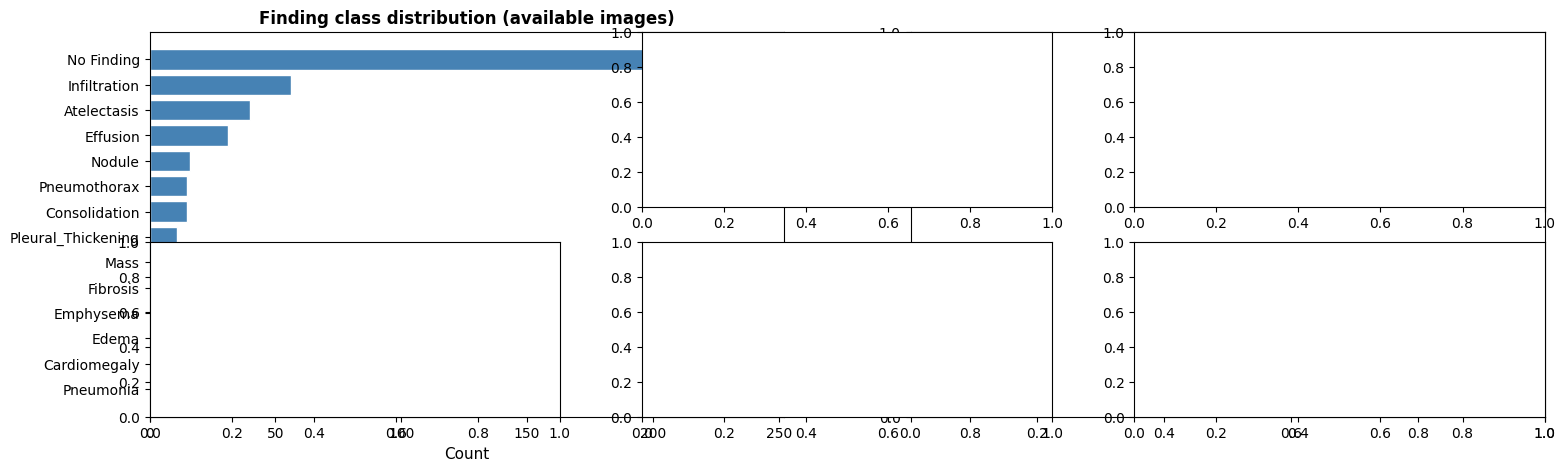

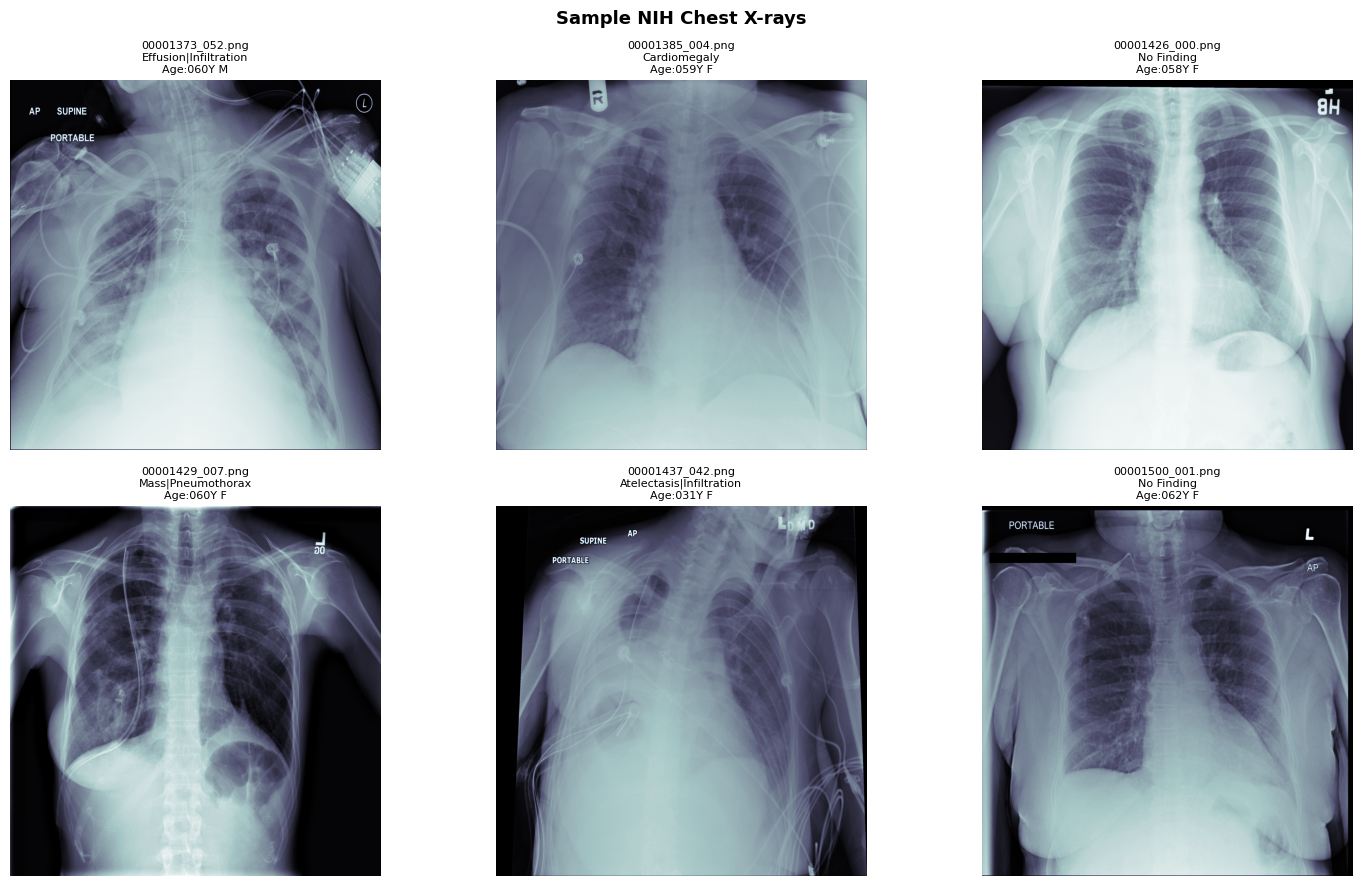


Class counts: {'No Finding': 240, 'Infiltration': 56, 'Atelectasis': 40, 'Effusion': 31, 'Nodule': 16, 'Pneumothorax': 15, 'Consolidation': 15, 'Pleural_Thickening': 11, 'Mass': 10, 'Fibrosis': 9, 'Emphysema': 7, 'Edema': 5, 'Cardiomegaly': 4, 'Pneumonia': 1}


In [15]:
# ── NIH Chest X-ray Dataset Exploration ──────────────────────────────────────
import os, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

NIH_DIR    = os.path.join(VISTA_ROOT, 'NIHChest', 'extracted', 'NIHChest')
LABELS_CSV = os.path.join(NIH_DIR, 'labels.csv')
IMAGES_DIR = os.path.join(NIH_DIR, 'images')

ALL_CLASSES = [
    'Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax',
    'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia',
    'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia', 'No Finding'
]

df = pd.read_csv(LABELS_CSV)
available = set(os.listdir(IMAGES_DIR))
df_avail  = df[df['Image Index'].isin(available)].reset_index(drop=True)
print(f'CSV rows: {len(df)}  |  Images on disk: {len(available)}  |  Matched: {len(df_avail)}')
print()
print(df_avail[['Image Index','Finding Labels','Patient Age','Patient Gender','View Position']].head(10).to_string())

# ── Class distribution ───────────────────────────────────────────────────────
label_counts = Counter()
for lbl_str in df_avail['Finding Labels']:
    for lbl in lbl_str.split('|'):
        label_counts[lbl.strip()] += 1

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sorted_lbl = sorted(label_counts.items(), key=lambda x: -x[1])
classes, counts = zip(*sorted_lbl)
axes[0].barh(classes, counts, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Count', fontsize=11)
axes[0].set_title('Finding class distribution (available images)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# ── Sample 6 images with labels ──────────────────────────────────────────────
sample6 = df_avail.head(6)
for i, (_, row) in enumerate(sample6.iterrows()):
    ax = axes[1] if i == 0 else fig.add_subplot(2, 3, i+1) if i < 6 else None

fig2, img_axes = plt.subplots(2, 3, figsize=(15, 9))
for i, (_, row) in enumerate(sample6.iterrows()):
    img = Image.open(os.path.join(IMAGES_DIR, row['Image Index'])).convert('L')
    ax = img_axes[i // 3][i % 3]
    ax.imshow(img, cmap='bone')
    ax.set_title(f"{row['Image Index']}\n{row['Finding Labels']}\nAge:{row['Patient Age']} {row['Patient Gender']}",
                 fontsize=8)
    ax.axis('off')

plt.suptitle('Sample NIH Chest X-rays', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\nClass counts: {dict(sorted_lbl)}')


In [ ]:
# ── VISTA on NIH Chest X-rays: Baseline vs VISTA (VSV+SLA) ───────────────────
# Uses llava.mm_utils.process_images — same preprocessing as official LLaVA CLI.
from llava.mm_utils import process_images
from PIL import Image as PILImage

# Pick 10 images that are present on disk
NIH_SAMPLE = df_avail.head(10).reset_index(drop=True)

DESCRIBE_PROMPT = (
    'This is a chest X-ray. '
    'First, describe the key visual findings you observe (lung fields, heart, '
    'pleural spaces, bones, any abnormalities). '
    'Then on a new line write: CLASSIFICATION: followed by all applicable '
    'conditions from this list separated by commas — '
    'Atelectasis, Consolidation, Infiltration, Pneumothorax, Edema, Emphysema, '
    'Fibrosis, Effusion, Pneumonia, Pleural_Thickening, Cardiomegaly, '
    'Nodule, Mass, Hernia, No Finding.'
)

def nih_infer(image_path, use_vsv, use_sla, max_tokens=220):
    from PIL import Image as PILImage
    """Run LLaVA (optionally with VISTA) on a single chest X-ray."""
    args.vsv = use_vsv
    args.logits_aug = use_sla

    raw = PILImage.open(image_path).convert('RGB')
    pv = process_images([raw], model_loader.image_processor, model_loader.vlm_model.config)
    proc = {"pixel_values": pv}

    with torch.inference_mode():
        with myutils.maybe_autocast(MODEL_NAME, model_loader.vlm_model.device):
            questions, model_gen_kwargs = model_loader.prepare_inputs_for_model(
                template, [DESCRIBE_PROMPT], proc
            )
            if use_vsv:
                neg_kw = model_loader.prepare_neg_prompt(args, questions, template=template)
                pos_kw = model_loader.prepare_pos_prompt(args, model_gen_kwargs)
                vec, _ = obtain_vsv(args, model_loader.llm_model, [[neg_kw, pos_kw]])
                add_vsv_layers(
                    model_loader.llm_model,
                    torch.stack([vec], dim=1).cuda(),
                    [args.vsv_lambda],
                )
            add_logits_flag(model_loader.llm_model, args)
            out = model_loader.llm_model.generate(
                do_sample=False,
                max_new_tokens=max_tokens,
                use_cache=True,
                num_beams=1,
                output_attentions=False,
                output_hidden_states=use_sla,
                temperature=1.0,
                repetition_penalty=1.0,
                return_dict=True,
                **model_gen_kwargs,
            )
            remove_logits_flag(model_loader.llm_model)
            if use_vsv:
                remove_vsv_layers(model_loader.llm_model)
    return model_loader.decode(out)[0]

def extract_classification(text):
    """Pull the CLASSIFICATION: line from the model response."""
    for line in text.split("\n"):
        if "CLASSIFICATION" in line.upper():
            return line.split(":", 1)[-1].strip()
    return "(not found)"

def match_score(predicted, ground_truth_str):
    """Count how many GT labels appear in the predicted text."""
    gt_labels = [l.strip().lower() for l in ground_truth_str.split("|")]
    pred_lower = predicted.lower()
    hits = sum(1 for l in gt_labels if l in pred_lower)
    return hits, len(gt_labels)

# ── Run inference ─────────────────────────────────────────────────────────────
nih_results = []
for idx, row in NIH_SAMPLE.iterrows():
    img_path = os.path.join(IMAGES_DIR, row["Image Index"])
    print(f'[{idx+1}/10] {row["Image Index"]}  GT: {row["Finding Labels"]}')

    base_out = nih_infer(img_path, use_vsv=False, use_sla=False)
    vista_out = nih_infer(img_path, use_vsv=True, use_sla=True)

    nih_results.append(
        {
            "image_path": img_path,
            "image_index": row["Image Index"],
            "ground_truth": row["Finding Labels"],
            "patient_info": f"Age {row['Patient Age']} | {row['Patient Gender']} | {row['View Position']}",
            "baseline": base_out,
            "vista": vista_out,
        }
    )
    print(f"  Baseline class : {extract_classification(base_out)}")
    print(f"  VISTA class    : {extract_classification(vista_out)}")
    print()

print("Inference complete.")


In [ ]:
# ── Display: chest X-ray | Baseline | VISTA ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap
from PIL import Image as PILImage

def wrap(text, width=52):
    return '\n'.join(textwrap.wrap(text, width))

n = len(nih_results)
fig, axes = plt.subplots(n, 3, figsize=(18, 5.5 * n),
                          gridspec_kw={'width_ratios': [1.6, 3, 3]})
if n == 1: axes = [axes]

for i, r in enumerate(nih_results):
    ax_img, ax_base, ax_vista = axes[i]

    # ── X-ray image ──────────────────────────────────────────────────────────
    img = PILImage.open(r['image_path']).convert('L')
    ax_img.imshow(img, cmap='bone')
    ax_img.axis('off')
    ax_img.set_title(
        f"Example {i+1}\n{r['image_index']}\n{r['patient_info']}",
        fontsize=9, fontweight='bold'
    )
    ax_img.text(0.5, -0.04,
                f"GT: {r['ground_truth']}",
                transform=ax_img.transAxes, fontsize=8,
                ha='center', color='darkred', style='italic')

    # ── Helper to render a text panel ────────────────────────────────────────
    def render_panel(ax, title, response, bg):
        ax.set_facecolor(bg)
        ax.axis('off')
        ax.set_title(title, fontsize=11, fontweight='bold', color='#1a252f', pad=8)

        cls_line = extract_classification(response)
        b_hits, b_tot = match_score(response, r['ground_truth'])

        # Split into description and classification parts
        if 'CLASSIFICATION' in response.upper():
            parts = response.upper().split('CLASSIFICATION')
            desc_text = wrap(response[:len(parts[0])].strip(), 58)
        else:
            desc_text = wrap(response.strip(), 58)

        body = f"DESCRIPTION:\n{desc_text}\n\nCLASSIFICATION:\n{wrap(cls_line, 55)}"
        ax.text(0.03, 0.97, body, transform=ax.transAxes,
                fontsize=9, va='top', ha='left', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.88))

        score_color = '#27ae60' if b_hits == b_tot else ('#e67e22' if b_hits > 0 else '#e74c3c')
        ax.text(0.97, 0.03,
                f'Label match: {b_hits}/{b_tot}',
                transform=ax.transAxes, fontsize=10, fontweight='bold',
                va='bottom', ha='right', color=score_color)

    render_panel(ax_base,  'Baseline LLaVA 1.5',  r['baseline'], '#fdfefe')
    render_panel(ax_vista, 'VISTA (VSV + SLA)',    r['vista'],    '#eaf4fb')

plt.suptitle('NIH Chest X-ray Analysis: Baseline LLaVA vs VISTA',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(VISTA_ROOT, 'nih_vista_comparison.png'),
            dpi=110, bbox_inches='tight')
plt.show()
print('Figure saved to nih_vista_comparison.png')


In [ ]:
# ── Disease-wise QA setup (14 classes; yes/no + region) ───────────────────────
import re
import pandas as pd
from llava.mm_utils import process_images
from PIL import Image as PILImage

# NIH 14 disease classes (excluding "No Finding")
DISEASES_14 = [
    "Atelectasis",
    "Consolidation",
    "Infiltration",
    "Pneumothorax",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Effusion",
    "Pneumonia",
    "Pleural_Thickening",
    "Cardiomegaly",
    "Nodule",
    "Mass",
    "Hernia",
]

# Keep runtime manageable: 10 images by default (you can change)
NIH_QA_SAMPLE = df_avail.head(10).reset_index(drop=True)

def _make_disease_prompt(disease_name):
    return (
        f"You are given a chest X-ray. Is {disease_name} present? "
        "Answer with this strict format: "
        "YESNO: <Yes or No>\n"
        "REGION: <short region description where signs are present; if absent, write 'N/A'>\n"
        "REASON: <very brief finding-based reason>."
    )


def _parse_yesno_region(text):
    # Robust parser for slightly non-strict model output
    t = text.strip()

    # YESNO extraction
    yn = None
    m = re.search(r"YESNO\s*:\s*(Yes|No)", t, flags=re.IGNORECASE)
    if m:
        yn = m.group(1).capitalize()
    else:
        low = t.lower()
        if low.startswith("yes") or " yes" in low:
            yn = "Yes"
        elif low.startswith("no") or " no" in low:
            yn = "No"
        else:
            yn = "Unknown"

    # REGION extraction
    region = ""
    m = re.search(r"REGION\s*:\s*(.+)", t, flags=re.IGNORECASE)
    if m:
        region = m.group(1).strip()
        # trim if REASON is on same line
        region = re.split(r"REASON\s*:", region, flags=re.IGNORECASE)[0].strip()
    if not region:
        region = "N/A" if yn == "No" else "(not specified)"

    return yn, region


In [ ]:
# ── Run disease-wise QA: 14 questions per image (Baseline + VISTA) ────────────

def disease_qa_infer(image_path, disease_name, use_vsv, use_sla, max_tokens=96):
    args.vsv = use_vsv
    args.logits_aug = use_sla

    raw = PILImage.open(image_path).convert("RGB")
    pv = process_images([raw], model_loader.image_processor, model_loader.vlm_model.config)
    proc = {"pixel_values": pv}

    prompt = _make_disease_prompt(disease_name)

    with torch.inference_mode():
        with myutils.maybe_autocast(MODEL_NAME, model_loader.vlm_model.device):
            questions, model_gen_kwargs = model_loader.prepare_inputs_for_model(
                template, [prompt], proc
            )

            if use_vsv:
                neg_kw = model_loader.prepare_neg_prompt(args, questions, template=template)
                pos_kw = model_loader.prepare_pos_prompt(args, model_gen_kwargs)
                vec, _ = obtain_vsv(args, model_loader.llm_model, [[neg_kw, pos_kw]])
                add_vsv_layers(
                    model_loader.llm_model,
                    torch.stack([vec], dim=1).cuda(),
                    [args.vsv_lambda],
                )

            add_logits_flag(model_loader.llm_model, args)
            out = model_loader.llm_model.generate(
                do_sample=False,
                max_new_tokens=max_tokens,
                use_cache=True,
                num_beams=1,
                output_attentions=False,
                output_hidden_states=use_sla,
                temperature=1.0,
                repetition_penalty=1.0,
                return_dict=True,
                **model_gen_kwargs,
            )

            remove_logits_flag(model_loader.llm_model)
            if use_vsv:
                remove_vsv_layers(model_loader.llm_model)

    text = model_loader.decode(out)[0]
    yn, region = _parse_yesno_region(text)
    return text, yn, region


# This creates 10 * 14 = 140 QA rows per model setting
# and runs both Baseline and VISTA -> 280 total generations.
# Reduce NIH_QA_SAMPLE if you need a faster run.
nih_disease_rows = []

for i, row in NIH_QA_SAMPLE.iterrows():
    img_path = os.path.join(IMAGES_DIR, row["Image Index"])
    gt_labels = row["Finding Labels"]
    print(f"[{i+1}/{len(NIH_QA_SAMPLE)}] {row['Image Index']}  GT: {gt_labels}")

    for d in DISEASES_14:
        # Baseline
        base_text, base_yn, base_region = disease_qa_infer(
            img_path, d, use_vsv=False, use_sla=False
        )

        # VISTA
        vista_text, vista_yn, vista_region = disease_qa_infer(
            img_path, d, use_vsv=True, use_sla=True
        )

        nih_disease_rows.append({
            "image_index": row["Image Index"],
            "image_path": img_path,
            "ground_truth_labels": gt_labels,
            "disease": d,
            "baseline_yesno": base_yn,
            "baseline_region": base_region,
            "baseline_raw": base_text,
            "vista_yesno": vista_yn,
            "vista_region": vista_region,
            "vista_raw": vista_text,
        })

nih_disease_df = pd.DataFrame(nih_disease_rows)
print(f"Done. Generated {len(nih_disease_df)} rows.")
nih_disease_df.head(20)


In [ ]:
# ── Display + save results ─────────────────────────────────────────────────────
# Wide view for easy per-image comparison
show_cols = [
    "image_index",
    "disease",
    "ground_truth_labels",
    "baseline_yesno",
    "baseline_region",
    "vista_yesno",
    "vista_region",
]

display_df = nih_disease_df[show_cols].copy()

# Optional quick scoring (weak heuristic): treat GT string contains disease name as positive
# Note: GT can be multi-label and naming variations exist.
def _gt_has_disease(gt, disease):
    gt_low = gt.lower()
    d_low = disease.lower().replace("_", " ")
    return d_low in gt_low

display_df["gt_yesno"] = display_df.apply(
    lambda r: "Yes" if _gt_has_disease(r["ground_truth_labels"], r["disease"]) else "No",
    axis=1,
)

baseline_acc = (display_df["baseline_yesno"] == display_df["gt_yesno"]).mean()
vista_acc = (display_df["vista_yesno"] == display_df["gt_yesno"]).mean()
print(f"Baseline yes/no match (heuristic): {baseline_acc:.3f}")
print(f"VISTA yes/no match (heuristic):    {vista_acc:.3f}")

out_csv = os.path.join(VISTA_ROOT, "nih_disease_qa_results.csv")
display_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

# Show first 56 rows (= first 4 images x 14 diseases)
display_df.head(56)
